In [145]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix , accuracy_score


loading Dataset

In [146]:
#Loading the dataset

df = pd.read_csv('Coding_Assesment.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [147]:
df.shape

(1470, 35)

In [148]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [149]:
print(df['Attrition'].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [151]:
drop_cols = ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
df.drop(drop_cols, axis=1, inplace=True)

Preprocessing

In [152]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [153]:
# spliting the data into training and testing sets
X = df.drop('Attrition', axis=1)
y = df['Attrition']

cat_cols = X.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [154]:
#one hot encoding 

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(X.dtypes)

Age                                  int64
DailyRate                            int64
DistanceFromHome                     int64
Education                            int64
EnvironmentSatisfaction              int64
HourlyRate                           int64
JobInvolvement                       int64
JobLevel                             int64
JobSatisfaction                      int64
MonthlyIncome                        int64
MonthlyRate                          int64
NumCompaniesWorked                   int64
PercentSalaryHike                    int64
PerformanceRating                    int64
RelationshipSatisfaction             int64
StockOptionLevel                     int64
TotalWorkingYears                    int64
TrainingTimesLastYear                int64
WorkLifeBalance                      int64
YearsAtCompany                       int64
YearsInCurrentRole                   int64
YearsSinceLastPromotion              int64
YearsWithCurrManager                 int64
BusinessTra

In [155]:
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [156]:
print(X.dtypes)

Age                                  int64
DailyRate                            int64
DistanceFromHome                     int64
Education                            int64
EnvironmentSatisfaction              int64
HourlyRate                           int64
JobInvolvement                       int64
JobLevel                             int64
JobSatisfaction                      int64
MonthlyIncome                        int64
MonthlyRate                          int64
NumCompaniesWorked                   int64
PercentSalaryHike                    int64
PerformanceRating                    int64
RelationshipSatisfaction             int64
StockOptionLevel                     int64
TotalWorkingYears                    int64
TrainingTimesLastYear                int64
WorkLifeBalance                      int64
YearsAtCompany                       int64
YearsInCurrentRole                   int64
YearsSinceLastPromotion              int64
YearsWithCurrManager                 int64
BusinessTra

In [157]:
Q1 = df['MonthlyIncome'].quantile(0.25)
Q3 = df['MonthlyIncome'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['MonthlyIncome'] < lower) | (df['MonthlyIncome'] > upper)]
print("Number of outliers in MonthlyIncome:", outliers.shape[0])

Number of outliers in MonthlyIncome: 114


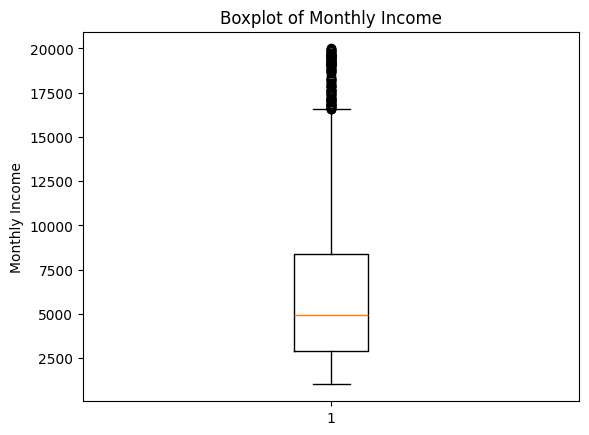

In [158]:
plt.boxplot(df['MonthlyIncome'])
plt.title('Boxplot of Monthly Income')
plt.ylabel('Monthly Income')
plt.show()

Spliting the dataset 

In [159]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [160]:
from imblearn.over_sampling import SMOTE
S = SMOTE(random_state=42)
X_train, y_train_sm = S.fit_resample(X_train, y_train)

In [161]:
print("Before SMOTE value counts:",y_train.value_counts())
print("After SMOTE value counts:",y_train_sm.value_counts())


Before SMOTE value counts: Attrition
No     978
Yes    198
Name: count, dtype: int64
After SMOTE value counts: Attrition
No     978
Yes    978
Name: count, dtype: int64


Model Building

Logistic Regression

In [162]:
lr = LogisticRegression(max_iter = 2000)
lr.fit(X_train, y_train_sm)

y_pred = lr.predict(X_test)
print(y_pred)

['No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No'
 'No' 'Yes' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No'
 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'Yes' 'Yes'
 'No' 'No' 'Yes' 'No' 'Yes' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No'
 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No'
 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'No'
 'No' 'Yes' 'No' 'Yes' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No'
 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'Yes' 'Yes'
 'No' 'No' 'No' 'Yes' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes'
 'Yes' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No' 'Yes'
 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No' 'No' 'No'
 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'Yes' 'No'
 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'Yes' 'No' 'No' 'No'
 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 

c:\Users\PRIYANSHU\OneDrive\Desktop\MLTP\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [163]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.7721088435374149


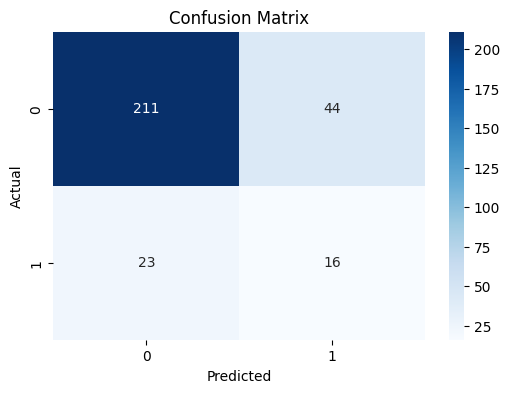

In [164]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [165]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.90      0.83      0.86       255
         Yes       0.27      0.41      0.32        39

    accuracy                           0.77       294
   macro avg       0.58      0.62      0.59       294
weighted avg       0.82      0.77      0.79       294



Decision Tree

In [166]:
X = X.drop('MonthlyIncome', axis=1)


dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train_sm)

y_pred_dt = dt.predict(X_test)    

In [167]:
print("Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Accuracy Score:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Classification Report:
               precision    recall  f1-score   support

          No       0.90      0.84      0.87       255
         Yes       0.27      0.38      0.32        39

    accuracy                           0.78       294
   macro avg       0.58      0.61      0.59       294
weighted avg       0.82      0.78      0.79       294

Accuracy Score: 0.7789115646258503
Confusion Matrix:
 [[214  41]
 [ 24  15]]


Random Forest

In [168]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train_sm)

y_pred_rf = rf.predict(X_test)

In [169]:
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Accuracy Score:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Classification Report:
               precision    recall  f1-score   support

          No       0.92      0.91      0.91       255
         Yes       0.43      0.46      0.44        39

    accuracy                           0.85       294
   macro avg       0.67      0.68      0.68       294
weighted avg       0.85      0.85      0.85       294

Accuracy Score: 0.8469387755102041
Confusion Matrix:
 [[231  24]
 [ 21  18]]


Comparison Between Logistic Regression , Decision tree , Random Forest 

In [170]:
print("Logistic Regression Accuracy Score:", accuracy_score(y_test, y_pred))
print("Decision Tree Accuracy Score:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy Score:", accuracy_score(y_test, y_pred_rf))


Logistic Regression Accuracy Score: 0.7721088435374149
Decision Tree Accuracy Score: 0.7789115646258503
Random Forest Accuracy Score: 0.8469387755102041


In [171]:
print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Random Forest Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Logistic Regression Confusion Matrix:
 [[211  44]
 [ 23  16]]
Decision Tree Confusion Matrix:
 [[214  41]
 [ 24  15]]
Random Forest Confusion Matrix:
 [[231  24]
 [ 21  18]]


In [172]:
print("Logistic Regression Classification Report:\n", classification_report(y_test, y_pred))
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))
print("Random Forest Classification Report:\n", classification_report(y_test, y_pred_rf))


Logistic Regression Classification Report:
               precision    recall  f1-score   support

          No       0.90      0.83      0.86       255
         Yes       0.27      0.41      0.32        39

    accuracy                           0.77       294
   macro avg       0.58      0.62      0.59       294
weighted avg       0.82      0.77      0.79       294

Decision Tree Classification Report:
               precision    recall  f1-score   support

          No       0.90      0.84      0.87       255
         Yes       0.27      0.38      0.32        39

    accuracy                           0.78       294
   macro avg       0.58      0.61      0.59       294
weighted avg       0.82      0.78      0.79       294

Random Forest Classification Report:
               precision    recall  f1-score   support

          No       0.92      0.91      0.91       255
         Yes       0.43      0.46      0.44        39

    accuracy                           0.85       294
   macro